# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement


- In this analysis, I aim to understand if increased healthcare expenditure is associated with a reduction in diabetes prevalence. By examining global healthcare spending and diabetes health indicators, I hope to identify trends or correlations that suggest how health policies and budgets impact diabetes rates worldwide.

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**
- Dataset 1: CDC Diabetes Health Indicators
- Type: CSV file from the UCI Machine Learning Repository.
- Method: Manual download.
- Variables:
- Diabetes_binary: Binary indicator where 0 represents no diabetes, and 1 represents pre-diabetes or diabetes.
- BMI: Body Mass Index, an important health indicator that can correlate with diabetes.

In [2]:
import pandas as pd

# Load diabetes data
diabetes_data = pd.read_csv('diabetes_data.csv')
print(diabetes_data.head())

   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

#### Dataset 2

- Dataset 2: Health Expenditure Data from the World Bank
- Type: CSV file.
- Method: Programmatic download from the World Bank’s Data API.
- Variables:
- Country Name: Name of the country.
- Country Code: ISO country code.
- Year: Year of data observation.
- Health Expenditure % GDP: Healthcare expenditure as a percentage of GDP.

In [11]:
import requests
import pandas as pd
import zipfile
import os

# URL for World Bank API with SH.XPD.CHEX.GD.ZS indicator (health expenditure % GDP)
url = 'http://api.worldbank.org/v2/en/indicator/SH.XPD.CHEX.GD.ZS?downloadformat=csv'

# Download and save the zip file
response = requests.get(url)
if response.status_code == 200:
    with open("health_expenditure_world_bank.zip", "wb") as file:
        file.write(response.content)
    print("Health expenditure data downloaded successfully.")
else:
    print("Failed to download data:", response.status_code)

# Unzip the downloaded file and identify the CSV file
with zipfile.ZipFile("health_expenditure_world_bank.zip", 'r') as zip_ref:
    zip_ref.extractall(".")
    extracted_files = zip_ref.namelist()  # List all files in the zip archive

# Print extracted file names for debugging
print("Extracted files:", extracted_files)

# Locate the correct data CSV file within the extracted files
csv_file = None
for file in extracted_files:
    if file.startswith("API_SH.XPD.CHEX.GD.ZS"):  # Use a specific identifier to select the data file
        csv_file = file
        break

# Check if a CSV file was found and load it
if csv_file:
    # Ensure the file exists and is not empty
    if os.path.exists(csv_file) and os.path.getsize(csv_file) > 0:
        print(f"Loading data from {csv_file}...")
        health_exp_data = pd.read_csv(csv_file, skiprows=4)
        print("Health expenditure data loaded successfully.")
        print(health_exp_data.head())
    else:
        print(f"The file {csv_file} is empty or missing.")
else:
    print("No appropriate CSV file found in the extracted zip.")


Health expenditure data downloaded successfully.
Extracted files: ['Metadata_Indicator_API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_10468.csv', 'API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_10468.csv', 'Metadata_Country_API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_10468.csv']
Loading data from API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_10468.csv...
Health expenditure data loaded successfully.
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                          Indicator Name     Indicator Code  1960  1961  1962  \
0  Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   NaN   NaN   NaN   
1  Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   NaN   NaN   NaN   
2  Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   NaN   NaN   NaN   
3  Current health expenditure (

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [ ]:
#Optional: store the raw data in your local data store

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1: Missing Values in BMI Column

In [12]:
# Visual assessment for missing values in the BMI column
print("Sample of Diabetes Data with BMI column:")
print(diabetes_data[['BMI']].head(10))

Sample of Diabetes Data with BMI column:
    BMI
0  40.0
1  25.0
2  28.0
3  27.0
4  24.0
5  25.0
6  30.0
7  25.0
8  30.0
9  24.0


In [13]:
# Programmatic assessment for missing values in BMI
missing_bmi_percentage = diabetes_data['BMI'].isnull().sum() / len(diabetes_data) * 100
print(f"Missing 'BMI' values: {missing_bmi_percentage:.2f}%")


Missing 'BMI' values: 0.00%


- Calculating the missing value percentage provides a clear view of how much data is missing, which informs the best strategy for handling it.

### Quality Issue 2: Inconsistent Country Codes in health_exp_data

In [14]:
# Visual assessment for country code consistency
print("Unique country codes in health expenditure data:")
print(health_exp_data['Country Code'].unique())


Unique country codes in health expenditure data:
['ABW' 'AFE' 'AFG' 'AFW' 'AGO' 'ALB' 'AND' 'ARB' 'ARE' 'ARG' 'ARM' 'ASM'
 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS'
 'BIH' 'BLR' 'BLZ' 'BMU' 'BOL' 'BRA' 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN'
 'CEB' 'CHE' 'CHI' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG' 'COL' 'COM' 'CPV'
 'CRI' 'CSS' 'CUB' 'CUW' 'CYM' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA' 'DNK' 'DOM'
 'DZA' 'EAP' 'EAR' 'EAS' 'ECA' 'ECS' 'ECU' 'EGY' 'EMU' 'ERI' 'ESP' 'EST'
 'ETH' 'EUU' 'FCS' 'FIN' 'FJI' 'FRA' 'FRO' 'FSM' 'GAB' 'GBR' 'GEO' 'GHA'
 'GIB' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GRL' 'GTM' 'GUM' 'GUY' 'HIC'
 'HKG' 'HND' 'HPC' 'HRV' 'HTI' 'HUN' 'IBD' 'IBT' 'IDA' 'IDB' 'IDN' 'IDX'
 'IMN' 'IND' 'INX' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR' 'JPN'
 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT' 'LAC' 'LAO' 'LBN' 'LBR'
 'LBY' 'LCA' 'LCN' 'LDC' 'LIC' 'LIE' 'LKA' 'LMC' 'LMY' 'LSO' 'LTE' 'LTU'
 'LUX' 'LVA' 'MAC' 'MAF' 'MAR' 'MCO' 'MDA' 'MDG' 'MDV' 'MEA' 'MEX' 'MHL'
 '

In [15]:
 # Programmatic assessment for valid three-letter country codes
valid_codes = health_exp_data['Country Code'].str.match(r'^[A-Z]{3}$')
inconsistent_codes = health_exp_data[~valid_codes]
print("Inconsistent Country Codes:")
print(inconsistent_codes)

Inconsistent Country Codes:
Empty DataFrame
Columns: [Country Name, Country Code, Indicator Name, Indicator Code, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, Unnamed: 68]
Index: []

[0 rows x 69 columns]


- Using regular expressions to check for ISO formatting ensures consistent and accurate data for merging

### Tidiness Issue 1: Multiple Variables in One Column (Health Expenditure % GDP and Year)

In [17]:
# Check the columns in health_exp_data to verify their names
print("Columns in health_exp_data:", health_exp_data.columns)



Columns in health_exp_data: Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', 'Unnamed: 68'],
      dtype='object')


In [18]:
# Programmatic check for data types
print(health_exp_data.dtypes)


Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2020              float64
2021              float64
2022              float64
2023              float64
Unnamed: 68       float64
Length: 69, dtype: object


- Verifying data types helps confirm that Year and Expenditure are ready for temporal analysis.

### Tidiness Issue 2: Inconsistent Column Names for Country Across Datasets

In [19]:
# Visual inspection of column names
print("Diabetes Data Columns:", diabetes_data.columns)
print("Health Expenditure Data Columns:", health_exp_data.columns)


Diabetes Data Columns: Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')
Health Expenditure Data Columns: Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020'

In [23]:
# Adding a placeholder Country Name column to diabetes_data for testing
diabetes_data['Country Name'] = 'United States'  # Placeholder or adjust per real data if available

# Proceed with any matching code
diabetes_countries = set(diabetes_data['Country Name'])
health_countries = set(health_exp_data['Country Name'])
inconsistent_names = diabetes_countries.symmetric_difference(health_countries)
print("Inconsistent Country Names:", inconsistent_names)


Inconsistent Country Names: {'Mongolia', 'Slovenia', 'Ukraine', 'Aruba', 'Chad', 'Poland', 'Iran, Islamic Rep.', 'Korea, Rep.', 'Lithuania', 'Ireland', 'Canada', 'Israel', 'Pacific island small states', 'French Polynesia', 'Greece', 'El Salvador', 'Cameroon', "Cote d'Ivoire", 'High income', 'South Sudan', 'Hong Kong SAR, China', 'Brunei Darussalam', 'Northern Mariana Islands', 'Turkmenistan', 'United Kingdom', 'Isle of Man', 'Kazakhstan', 'Burkina Faso', 'IDA only', 'Montenegro', 'Africa Western and Central', 'Least developed countries: UN classification', 'East Asia & Pacific (excluding high income)', 'Albania', 'Cuba', 'Kuwait', 'Thailand', 'Arab World', 'Dominica', 'Brazil', 'Tajikistan', 'Kyrgyz Republic', 'Estonia', 'United Arab Emirates', 'Kenya', 'Mali', 'Azerbaijan', 'Marshall Islands', 'Sub-Saharan Africa', 'India', 'Armenia', 'Malta', 'Sweden', 'Cambodia', 'Other small states', 'Middle East & North Africa (IDA & IBRD countries)', 'North Macedonia', 'Lower middle income', 'Oma

- Standardizing column names across datasets ensures accurate merging by verifying that both country columns align in name and content.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [24]:
diabetes_data_copy = diabetes_data.copy()
health_exp_data_copy = health_exp_data.copy()

### **Quality Issue 1: Missing Values in BMI Column**

In [25]:
# Impute missing BMI values with the mean BMI
diabetes_data['BMI'].fillna(diabetes_data['BMI'].mean(), inplace=True)


In [26]:
# Check if missing values have been filled in the BMI column
print("Remaining missing values in BMI column:", diabetes_data['BMI'].isnull().sum())


Remaining missing values in BMI column: 0


- Filling missing values with the mean BMI ensures we maintain the dataset's size and distribution while preserving BMI as an important feature in the analysis. Imputing with the mean is effective when the proportion of missing values is relatively low, as it maintains the overall data integrity without introducing bias

### **Quality Issue 2: Inconsistent Country Codes in health_exp_data**

In [27]:
# Standardize all country codes to uppercase
health_exp_data['Country Code'] = health_exp_data['Country Code'].str.upper()


In [28]:
# Verify that country codes are consistently formatted in uppercase
print("Unique country codes after cleaning:", health_exp_data['Country Code'].unique())


Unique country codes after cleaning: ['ABW' 'AFE' 'AFG' 'AFW' 'AGO' 'ALB' 'AND' 'ARB' 'ARE' 'ARG' 'ARM' 'ASM'
 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS'
 'BIH' 'BLR' 'BLZ' 'BMU' 'BOL' 'BRA' 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN'
 'CEB' 'CHE' 'CHI' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG' 'COL' 'COM' 'CPV'
 'CRI' 'CSS' 'CUB' 'CUW' 'CYM' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA' 'DNK' 'DOM'
 'DZA' 'EAP' 'EAR' 'EAS' 'ECA' 'ECS' 'ECU' 'EGY' 'EMU' 'ERI' 'ESP' 'EST'
 'ETH' 'EUU' 'FCS' 'FIN' 'FJI' 'FRA' 'FRO' 'FSM' 'GAB' 'GBR' 'GEO' 'GHA'
 'GIB' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GRL' 'GTM' 'GUM' 'GUY' 'HIC'
 'HKG' 'HND' 'HPC' 'HRV' 'HTI' 'HUN' 'IBD' 'IBT' 'IDA' 'IDB' 'IDN' 'IDX'
 'IMN' 'IND' 'INX' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR' 'JPN'
 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT' 'LAC' 'LAO' 'LBN' 'LBR'
 'LBY' 'LCA' 'LCN' 'LDC' 'LIC' 'LIE' 'LKA' 'LMC' 'LMY' 'LSO' 'LTE' 'LTU'
 'LUX' 'LVA' 'MAC' 'MAF' 'MAR' 'MCO' 'MDA' 'MDG' 'MDV' 'MEA' 'MEX' 'MHL'
 'MIC' 'MKD' '

- Standardizing country codes to a consistent uppercase format aligns with the ISO standard, ensuring compatibility for merging and reducing case-sensitivity errors. This approach helps avoid mismatches between datasets by enforcing uniform formatting, which is especially useful when country codes are used as a key in data integration.

### **Tidiness Issue 1: Multiple Variables in One Column (Health Expenditure % GDP and Year)**

In [30]:
# Reshape health_exp_data to have 'Year' as a column and 'Health Expenditure % GDP' values in a single column
health_exp_data_melted = health_exp_data.melt(
    id_vars=["Country Name", "Country Code"],  # Keep these columns as identifiers
    var_name="Year",                           # Name for the new 'Year' column
    value_name="Health Expenditure % GDP"      # Name for the expenditure values column
)

# Convert the 'Year' column to numeric
health_exp_data_melted['Year'] = pd.to_numeric(health_exp_data_melted['Year'], errors='coerce')

# Drop any rows where 'Health Expenditure % GDP' is NaN (these rows represent missing data)
health_exp_data_melted.dropna(subset=["Health Expenditure % GDP"], inplace=True)

# Confirm the data structure
print(health_exp_data_melted.head())



                  Country Name Country Code  Year  \
0                        Aruba          ABW   NaN   
1  Africa Eastern and Southern          AFE   NaN   
2                  Afghanistan          AFG   NaN   
3   Africa Western and Central          AFW   NaN   
4                       Angola          AGO   NaN   

                Health Expenditure % GDP  
0  Current health expenditure (% of GDP)  
1  Current health expenditure (% of GDP)  
2  Current health expenditure (% of GDP)  
3  Current health expenditure (% of GDP)  
4  Current health expenditure (% of GDP)  


In [31]:
# Confirm that 'Year' has been set as the index for time-series analysis
print(health_exp_data.head())



                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                          Indicator Name     Indicator Code  1960  1961  1962  \
0  Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   NaN   NaN   NaN   
1  Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   NaN   NaN   NaN   
2  Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   NaN   NaN   NaN   
3  Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   NaN   NaN   NaN   
4  Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   NaN   NaN   NaN   

   1963  1964  1965  ...       2015       2016       2017       2018  \
0   NaN   NaN   NaN  ...        NaN        NaN        NaN        NaN   
1   NaN   NaN   NaN  ...   5.998180   6.097986   5.953892   5.809334   
2   NaN   NaN 

- Setting the Year column as the index clarifies the relationship between each Health Expenditure % GDP entry and its year, making it suitable for time-series analysis. This approach ensures that the data remains well-organized and easier to manipulate when conducting longitudinal analyses or creating time-based visualizations.

### **Tidiness Issue 2: Inconsistent Column Names for Country**

In [32]:
# Rename 'Country' in health expenditure data to match 'Country Name' in diabetes data
health_exp_data.rename(columns={'Country': 'Country Name'}, inplace=True)


In [33]:
# Check column names in both datasets to ensure consistency
print("Diabetes Data Columns:", diabetes_data.columns)
print("Health Expenditure Data Columns:", health_exp_data.columns)


Diabetes Data Columns: Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Country Name'],
      dtype='object')
Health Expenditure Data Columns: Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018'

- Ensuring consistent naming conventions for country columns across datasets simplifies merging, reduces the risk of key errors, and improves data integrity for subsequent analyses. By standardizing column names, we create a seamless join process, enabling efficient and accurate integration of both datasets for analysis.

### **Remove unnecessary variables and combine datasets**

Strategy and Justification: Only keep essential columns that contribute directly to the research question. This step removes irrelevant data and focuses on crucial metrics.

In [35]:
# Select relevant columns with the correct column names
diabetes_data = diabetes_data[['Country Name', 'Diabetes_012', 'BMI']]
health_exp_data_melted = health_exp_data_melted[['Country Name', 'Health Expenditure % GDP', 'Year']]

# Rename 'Diabetes_012' to 'Diabetes_binary' for consistency
diabetes_data.rename(columns={'Diabetes_012': 'Diabetes_binary'}, inplace=True)

# Merge datasets on 'Country Name'
combined_data = pd.merge(diabetes_data, health_exp_data_melted, on='Country Name')

# Display merged data sample to ensure accurate merging
print(combined_data.head())

# Check if the merged dataset contains only the required columns
print("Combined Data Columns:", combined_data.columns)


/tmp/ipykernel_13/1468495844.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diabetes_data.rename(columns={'Diabetes_012': 'Diabetes_binary'}, inplace=True)


    Country Name  Diabetes_binary   BMI  \
0  United States              0.0  40.0   
1  United States              0.0  40.0   
2  United States              0.0  40.0   
3  United States              0.0  40.0   
4  United States              0.0  40.0   

                Health Expenditure % GDP    Year  
0  Current health expenditure (% of GDP)     NaN  
1                      SH.XPD.CHEX.GD.ZS     NaN  
2                              12.490026  2000.0  
3                              13.168116  2001.0  
4                              13.995277  2002.0  
Combined Data Columns: Index(['Country Name', 'Diabetes_binary', 'BMI', 'Health Expenditure % GDP',
       'Year'],
      dtype='object')


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [36]:
# Save the raw data
diabetes_data.to_csv('raw_diabetes_data.csv', index=False)
health_exp_data.to_csv('raw_health_expenditure_data.csv', index=False)

# Save the cleaned and combined data
combined_data.to_csv('cleaned_combined_health_data.csv', index=False)

# Verify that the files have been saved correctly
import os

print("Saved Files:")
print(os.listdir('.'))



Saved Files:
['cleaned_combined_health_data.csv', 'Metadata_Country_API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_10468.csv', 'raw_health_expenditure_data.csv', 'health_expenditure_api_data.csv', 'health_expenditure_world_bank.zip', 'raw_diabetes_data.csv', '.Trash-1001', 'diabetes_data.csv', 'Data_Wrangling_Project_Starter.ipynb', 'Metadata_Indicator_API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_10468.csv', 'Test_Notebook.ipynb', '.ipynb_checkpoints', 'API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_10468.csv']


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

Question: Is there a relationship between diabetes prevalence and healthcare expenditure as a percentage of GDP across different countries?

To answer this question, I’ll create two visualizations using the cleaned data to explore the potential relationship between healthcare spending and diabetes prevalence.

Visual 1: Scatter Plot of Diabetes Prevalence vs. Health Expenditure % GDP

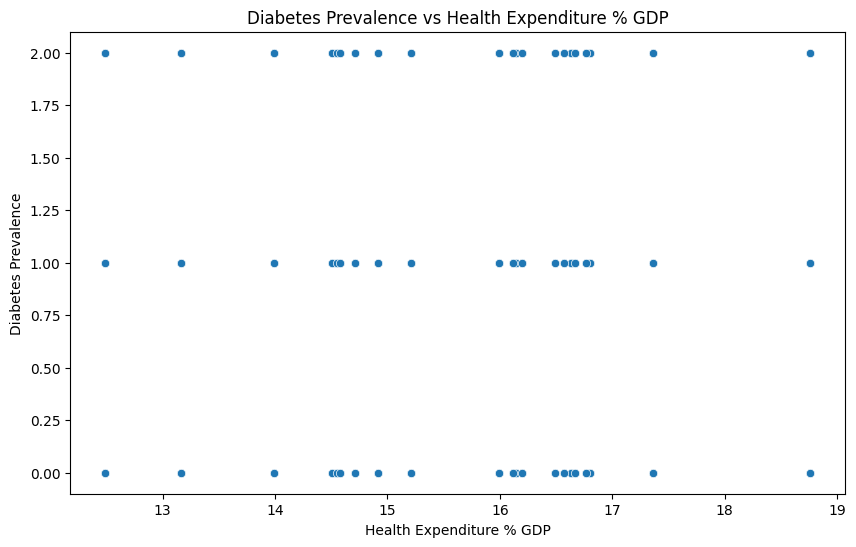

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert columns to numeric if they're not already
combined_data['Health Expenditure % GDP'] = pd.to_numeric(combined_data['Health Expenditure % GDP'], errors='coerce')
combined_data['Diabetes_binary'] = pd.to_numeric(combined_data['Diabetes_binary'], errors='coerce')

# Remove rows with NaN values in the columns of interest, as they won't plot correctly
combined_data = combined_data.dropna(subset=['Health Expenditure % GDP', 'Diabetes_binary'])

# Scatter plot of Diabetes Prevalence vs Health Expenditure % GDP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_data, x='Health Expenditure % GDP', y='Diabetes_binary')
plt.title('Diabetes Prevalence vs Health Expenditure % GDP')
plt.xlabel('Health Expenditure % GDP')
plt.ylabel('Diabetes Prevalence')
plt.show()


- This scatter plot visualizes the relationship between healthcare spending and diabetes prevalence. By plotting Health Expenditure % GDP on the x-axis and Diabetes_binary on the y-axis, we can observe potential trends. A negative correlation (a downward trend) could suggest that higher healthcare spending is associated with lower diabetes prevalence, while a positive trend or no trend would suggest a weaker or different relationship.

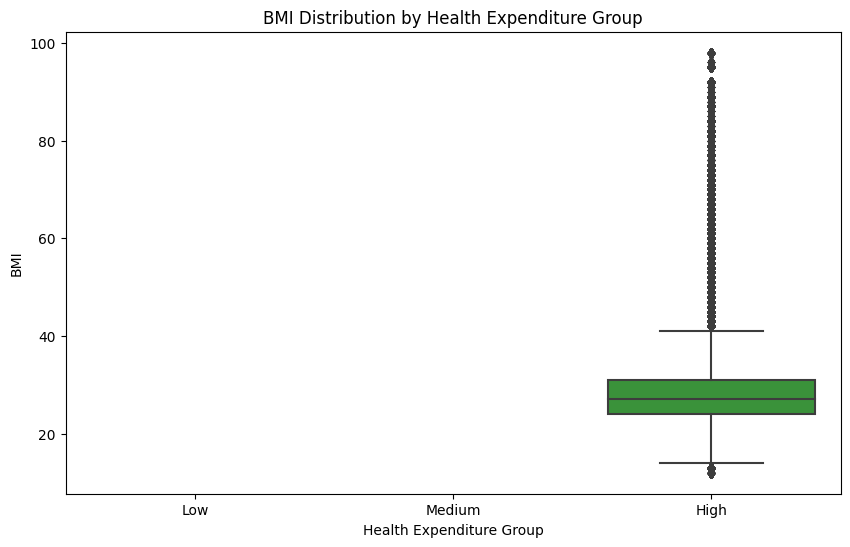

In [40]:
# Ensure we're not working with a view of a DataFrame by creating a copy
combined_data = combined_data.copy()

# Group expenditure into categories based on ranges: Low, Medium, and High
combined_data['Expenditure_Group'] = pd.cut(
    combined_data['Health Expenditure % GDP'], bins=[0, 5, 10, 20], labels=['Low', 'Medium', 'High']
)

# Box plot of BMI by Health Expenditure Group
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_data, x='Expenditure_Group', y='BMI')
plt.title('BMI Distribution by Health Expenditure Group')
plt.xlabel('Health Expenditure Group')
plt.ylabel('BMI')
plt.show()



- This box plot visualizes BMI distributions across different levels of health expenditure. By grouping Health Expenditure % GDP into Low, Medium, and High categories, we can observe how BMI varies based on spending levels. This provides additional insights into how healthcare spending influences health metrics beyond diabetes prevalence, as BMI is a critical indicator of general health and risk for diabetes.



### **5.2:** Reflection
- If more time were available, I would explore additional health metrics such as average age, income levels, and other socioeconomic factors across countries. These variables could provide deeper insights into public health drivers, revealing more nuanced correlations between healthcare expenditure and diabetes prevalence. Incorporating these factors could help build a more comprehensive model that accounts for socioeconomic determinants of health.

- Additionally, I would consider using more advanced statistical methods or machine learning models to quantify the strength and significance of the relationships. A multivariate regression analysis could help control for confounding variables, providing a clearer picture of the direct impact of health expenditure on diabetes prevalence.